# Proyecto Final AutoTec 

## Conexión y análisis operacional

Este notebook trabaja con la base/colección `Contenedor_Autos_Limpio1`, correspondiente a la base actualizada del proyecto AutoTec.

El objetivo inicial es validar la conexión a MongoDB, cargar los datos correctamente y preparar una base limpia para construir KPIs 100% operacionales orientados a supervisores.

In [1]:
import os
import numpy as np
import pandas as pd

from dotenv import load_dotenv
from pymongo import MongoClient

import matplotlib.pyplot as plt

In [2]:
# Cargar variables de entorno desde posibles ubicaciones
load_dotenv("/home/jovyan/work/.env")
load_dotenv("/home/jovyan/work/autotec/.env")
load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")

if MONGO_URI:
    print("✅ MONGO_URI encontrada correctamente")
    print("Inicio de la URI:", MONGO_URI[:30])
else:
    print("❌ No se encontró MONGO_URI")
    print("Revisa que exista un archivo .env con la variable MONGO_URI")

✅ MONGO_URI encontrada correctamente
Inicio de la URI: mongodb+srv://neiel_cortes:nei


In [3]:
try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.admin.command("ping")
    print("✅ Conexión exitosa a MongoDB")
except Exception as e:
    print("❌ Error de conexión a MongoDB")
    print(e)

✅ Conexión exitosa a MongoDB


In [4]:
print("Bases y colecciones disponibles:\n")

for db_name in client.list_database_names():
    print(f"BASE: {db_name}")
    
    if db_name not in ["admin", "local", "config"]:
        db = client[db_name]
        colecciones = db.list_collection_names()
        
        if colecciones:
            for col in colecciones:
                cantidad = db[col].count_documents({})
                print(f"   COLECCIÓN: {col} | Registros: {cantidad}")
        else:
            print("   Sin colecciones")
    
    print("-" * 50)

Bases y colecciones disponibles:

BASE: proyecto_bigdata
   COLECCIÓN: Contenedor_Autos_Limpio | Registros: 1988
   COLECCIÓN: bd_autos | Registros: 3554
   COLECCIÓN: lista_autos | Registros: 3627
   COLECCIÓN: marca_limpia | Registros: 3422
   COLECCIÓN: Contenedor_Autos_Limpio1 | Registros: 1685
--------------------------------------------------
BASE: prueba
   COLECCIÓN: personas | Registros: 2
--------------------------------------------------
BASE: admin
--------------------------------------------------
BASE: local
--------------------------------------------------


In [5]:
DATABASE_NAME = "proyecto_bigdata"
COLLECTION_NAME = "Contenedor_Autos_Limpio1"

db = client[DATABASE_NAME]
collection = db[COLLECTION_NAME]

cantidad_registros = collection.count_documents({})

print("Base de datos:", DATABASE_NAME)
print("Colección:", COLLECTION_NAME)
print("Cantidad de registros:", cantidad_registros)

Base de datos: proyecto_bigdata
Colección: Contenedor_Autos_Limpio1
Cantidad de registros: 1685


In [6]:
docs = list(collection.find({}, {"_id": 0}))

df = pd.DataFrame(docs)

print("Registros cargados:", len(df))
print("Columnas disponibles:")
print(df.columns.tolist())

df.head()

Registros cargados: 1685
Columnas disponibles:
['cat_combustible', 'categoria_precio', 'ciudad', 'combustible', 'fecha_captura', 'foto_url', 'grupo', 'kilometraje', 'marca', 'modelo', 'precio', 'rango_kilometraje', 'tipo_marca', 'url', 'uso_anual_estimado', 'usuario', 'year']


,cat_combustible,categoria_precio,ciudad,combustible,fecha_captura,foto_url,grupo,kilometraje,marca,modelo,precio,rango_kilometraje,tipo_marca,url,uso_anual_estimado,usuario,year
0,0,Medio,araucania,bencina,2026-05-31 19:47:03,,AutoTec,44387.0,changan,Cs55 1.5t Elite 4x2 At 5p,15490000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chang...,22193.500000,Luz Azocar,2024
1,0,Medio,santiago,bencina,2026-05-31 19:47:03,,AutoTec,75500.0,changan,Cs75,8000000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,8388.888889,Luz Azocar,2017
2,0,Medio,araucania,bencina,2026-05-31 19:47:58,,AutoTec,92300.0,changan,Cx70 1.6,7190000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,11537.500000,Luz Azocar,2018
3,0,Medio,santiago,bencina,2026-05-31 19:48:40,,AutoTec,87626.0,chery,Arrizo 1.5,6950000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chery...,29208.666667,Luz Azocar,2023
4,0,Medio,santiago,bencina,2026-05-31 19:47:10,,AutoTec,45050.0,chery,Tiggo 1.5t Glx 4x2 Cvt At 5p,12480000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chery...,9010.000000,Luz Azocar,2021


In [7]:
print("Dimensiones de la base:")
print(df.shape)

print("\nInformación de columnas:")
df.info()

Dimensiones de la base:
(1685, 17)

Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1685 entries, 0 to 1684
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cat_combustible     1685 non-null   int64  
 1   categoria_precio    1685 non-null   object 
 2   ciudad              1685 non-null   object 
 3   combustible         1685 non-null   object 
 4   fecha_captura       1685 non-null   object 
 5   foto_url            1318 non-null   object 
 6   grupo               1685 non-null   object 
 7   kilometraje         1685 non-null   float64
 8   marca               1685 non-null   object 
 9   modelo              1685 non-null   object 
 10  precio              1685 non-null   float64
 11  rango_kilometraje   1685 non-null   object 
 12  tipo_marca          1685 non-null   object 
 13  url                 1685 non-null   object 
 14  uso_anual_estimado  1627 non-null   float64

In [8]:
nulos = df.isnull().sum().reset_index()
nulos.columns = ["columna", "cantidad_nulos"]
nulos = nulos.sort_values("cantidad_nulos", ascending=False)

nulos

,columna,cantidad_nulos
5,foto_url,367
14,uso_anual_estimado,58
0,cat_combustible,0
9,modelo,0
15,usuario,0
13,url,0
12,tipo_marca,0
11,rango_kilometraje,0
10,precio,0
8,marca,0


In [9]:
def buscar_columna(df, opciones):
    for col in opciones:
        if col in df.columns:
            return col
    return None

col_marca = buscar_columna(df, ["marca", "Marca", "brand"])
col_modelo = buscar_columna(df, ["modelo", "Modelo", "model"])
col_precio = buscar_columna(df, ["precio_num", "precio", "Precio", "price"])
col_km = buscar_columna(df, ["km_num", "kilometraje", "Kilometraje", "kms", "km"])
col_year = buscar_columna(df, ["year_limpio", "year", "Year", "anio", "año", "Año"])
col_combustible = buscar_columna(df, ["combustible", "Combustible", "tipo_combustible", "fuel"])
col_ciudad = buscar_columna(df, ["ciudad", "Ciudad", "ciudad_o_comuna", "comuna", "ubicacion"])
col_url = buscar_columna(df, ["url", "URL", "link"])

columnas_detectadas = {
    "marca": col_marca,
    "modelo": col_modelo,
    "precio": col_precio,
    "kilometraje": col_km,
    "año": col_year,
    "combustible": col_combustible,
    "ciudad": col_ciudad,
    "url": col_url
}

columnas_detectadas

{'marca': 'marca',
 'modelo': 'modelo',
 'precio': 'precio',
 'kilometraje': 'kilometraje',
 'año': 'year',
 'combustible': 'combustible',
 'ciudad': 'ciudad',
 'url': 'url'}

In [10]:
def convertir_numero(serie):
    if pd.api.types.is_numeric_dtype(serie):
        return pd.to_numeric(serie, errors="coerce")
    
    return pd.to_numeric(
        serie.astype(str).str.replace(r"[^0-9]", "", regex=True),
        errors="coerce"
    )

In [11]:
df_op = df.copy()

df_op["marca_op"] = df_op[col_marca].astype(str).str.strip().str.title() if col_marca else "Sin marca"
df_op["modelo_op"] = df_op[col_modelo].astype(str).str.strip().str.title() if col_modelo else "Sin modelo"
df_op["combustible_op"] = df_op[col_combustible].astype(str).str.strip().str.title() if col_combustible else "Sin combustible"
df_op["ciudad_op"] = df_op[col_ciudad].astype(str).str.strip().str.title() if col_ciudad else "Sin ciudad"
df_op["url_op"] = df_op[col_url].astype(str).str.strip() if col_url else ""

df_op["precio_op"] = convertir_numero(df_op[col_precio]) if col_precio else np.nan
df_op["km_op"] = convertir_numero(df_op[col_km]) if col_km else np.nan
df_op["year_op"] = convertir_numero(df_op[col_year]) if col_year else np.nan

print("Registros antes de limpieza:", len(df_op))

df_op = df_op.dropna(subset=["precio_op", "km_op", "year_op"])

df_op = df_op[
    (df_op["precio_op"] > 0) &
    (df_op["km_op"] >= 0) &
    (df_op["year_op"] >= 1990)
].copy()

df_op["year_op"] = df_op["year_op"].astype(int)

print("Registros después de limpieza operacional:", len(df_op))

df_op.head()

Registros antes de limpieza: 1685
Registros después de limpieza operacional: 1685


,cat_combustible,categoria_precio,ciudad,combustible,fecha_captura,foto_url,grupo,kilometraje,marca,modelo,...,usuario,year,marca_op,modelo_op,combustible_op,ciudad_op,url_op,precio_op,km_op,year_op
0,0,Medio,araucania,bencina,2026-05-31 19:47:03,,AutoTec,44387.0,changan,Cs55 1.5t Elite 4x2 At 5p,...,Luz Azocar,2024,Changan,Cs55 1.5T Elite 4X2 At 5P,Bencina,Araucania,https://automoviles.emol.com/venta/autos/chang...,15490000.0,44387.0,2024
1,0,Medio,santiago,bencina,2026-05-31 19:47:03,,AutoTec,75500.0,changan,Cs75,...,Luz Azocar,2017,Changan,Cs75,Bencina,Santiago,https://automoviles.emol.com/venta/autos/chang...,8000000.0,75500.0,2017
2,0,Medio,araucania,bencina,2026-05-31 19:47:58,,AutoTec,92300.0,changan,Cx70 1.6,...,Luz Azocar,2018,Changan,Cx70 1.6,Bencina,Araucania,https://automoviles.emol.com/venta/autos/chang...,7190000.0,92300.0,2018
3,0,Medio,santiago,bencina,2026-05-31 19:48:40,,AutoTec,87626.0,chery,Arrizo 1.5,...,Luz Azocar,2023,Chery,Arrizo 1.5,Bencina,Santiago,https://automoviles.emol.com/venta/autos/chery...,6950000.0,87626.0,2023
4,0,Medio,santiago,bencina,2026-05-31 19:47:10,,AutoTec,45050.0,chery,Tiggo 1.5t Glx 4x2 Cvt At 5p,...,Luz Azocar,2021,Chery,Tiggo 1.5T Glx 4X2 Cvt At 5P,Bencina,Santiago,https://automoviles.emol.com/venta/autos/chery...,12480000.0,45050.0,2021


In [12]:
# Umbrales operacionales
umbral_km = 150000
umbral_year = 2014
percentil_precio = 95

limite_precio_alto = df_op["precio_op"].quantile(percentil_precio / 100)
limite_precio_bajo = df_op["precio_op"].quantile((100 - percentil_precio) / 100)
precio_mediano = df_op["precio_op"].median()

# Alerta 1: kilometraje crítico
df_op["alerta_km_critico"] = df_op["km_op"] >= umbral_km

# Alerta 2: año para revisión operacional
df_op["alerta_year_revision"] = df_op["year_op"] <= umbral_year

# Alerta 3: precio fuera de rango
df_op["alerta_precio_fuera_rango"] = (
    (df_op["precio_op"] >= limite_precio_alto) |
    (df_op["precio_op"] <= limite_precio_bajo)
)

# Alerta 4: datos incompletos en publicación
df_op["alerta_datos_incompletos"] = False

for col in ["marca_op", "modelo_op", "combustible_op", "ciudad_op"]:
    df_op["alerta_datos_incompletos"] = (
        df_op["alerta_datos_incompletos"] |
        df_op[col].isna() |
        df_op[col].astype(str).str.strip().isin([
            "",
            "Nan",
            "None",
            "Sin Marca",
            "Sin Modelo",
            "Sin Combustible",
            "Sin Ciudad"
        ])
    )

# Alerta 5: requiere revisión de publicación
df_op["alerta_revision_publicacion"] = (
    (df_op["km_op"] >= umbral_km) &
    (df_op["precio_op"] >= precio_mediano)
)

columnas_alertas = [
    "alerta_km_critico",
    "alerta_year_revision",
    "alerta_precio_fuera_rango",
    "alerta_datos_incompletos",
    "alerta_revision_publicacion"
]

df_op["total_alertas"] = df_op[columnas_alertas].sum(axis=1)

df_op["prioridad_operacional"] = np.select(
    [
        df_op["total_alertas"] >= 3,
        df_op["total_alertas"] == 2,
        df_op["total_alertas"] == 1
    ],
    [
        "Alta",
        "Media",
        "Baja"
    ],
    default="Sin alerta"
)

df_op[[
    "marca_op",
    "modelo_op",
    "year_op",
    "km_op",
    "precio_op",
    "total_alertas",
    "prioridad_operacional"
]].head()

,marca_op,modelo_op,year_op,km_op,precio_op,total_alertas,prioridad_operacional
0,Changan,Cs55 1.5T Elite 4X2 At 5P,2024,44387.0,15490000.0,0,Sin alerta
1,Changan,Cs75,2017,75500.0,8000000.0,0,Sin alerta
2,Changan,Cx70 1.6,2018,92300.0,7190000.0,0,Sin alerta
3,Chery,Arrizo 1.5,2023,87626.0,6950000.0,1,Baja
4,Chery,Tiggo 1.5T Glx 4X2 Cvt At 5P,2021,45050.0,12480000.0,0,Sin alerta


In [13]:
total_vehiculos = len(df_op)

def porcentaje(condicion):
    return round((condicion.sum() / total_vehiculos) * 100, 2)

tabla_kpis = pd.DataFrame({
    "KPI operacional": [
        "% vehículos con prioridad alta",
        "% vehículos con kilometraje crítico",
        "% vehículos con precio fuera de rango",
        "% publicaciones con datos incompletos",
        "% vehículos que requieren revisión de publicación"
    ],
    "Objetivo operacional": [
        "Priorizar revisión diaria de unidades críticas",
        "Detectar vehículos con alto nivel de uso",
        "Revisar precios extremos antes de publicar o vender",
        "Corregir información faltante en publicaciones",
        "Detectar autos con alto kilometraje y precio sobre la mediana"
    ],
    "Frecuencia": [
        "Diaria",
        "Diaria",
        "Diaria",
        "Diaria",
        "Diaria"
    ],
    "Valor KPI (%)": [
        porcentaje(df_op["prioridad_operacional"] == "Alta"),
        porcentaje(df_op["alerta_km_critico"]),
        porcentaje(df_op["alerta_precio_fuera_rango"]),
        porcentaje(df_op["alerta_datos_incompletos"]),
        porcentaje(df_op["alerta_revision_publicacion"])
    ]
})

tabla_kpis

,KPI operacional,Objetivo operacional,Frecuencia,Valor KPI (%)
0,% vehículos con prioridad alta,Priorizar revisión diaria de unidades críticas,Diaria,1.36
1,% vehículos con kilometraje crítico,Detectar vehículos con alto nivel de uso,Diaria,6.35
2,% vehículos con precio fuera de rango,Revisar precios extremos antes de publicar o v...,Diaria,10.09
3,% publicaciones con datos incompletos,Corregir información faltante en publicaciones,Diaria,0.00
4,% vehículos que requieren revisión de publicación,Detectar autos con alto kilometraje y precio s...,Diaria,1.31


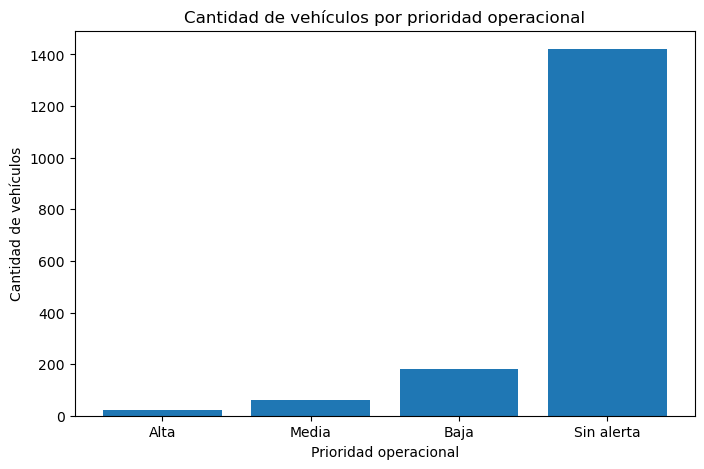

,prioridad_operacional,cantidad
3,Alta,23
2,Media,60
1,Baja,181
0,Sin alerta,1421


In [14]:
df_prioridad = df_op["prioridad_operacional"].value_counts().reset_index()
df_prioridad.columns = ["prioridad_operacional", "cantidad"]

orden = ["Alta", "Media", "Baja", "Sin alerta"]

df_prioridad["prioridad_operacional"] = pd.Categorical(
    df_prioridad["prioridad_operacional"],
    categories=orden,
    ordered=True
)

df_prioridad = df_prioridad.sort_values("prioridad_operacional")

plt.figure(figsize=(8, 5))
plt.bar(df_prioridad["prioridad_operacional"].astype(str), df_prioridad["cantidad"])
plt.title("Cantidad de vehículos por prioridad operacional")
plt.xlabel("Prioridad operacional")
plt.ylabel("Cantidad de vehículos")
plt.show()

df_prioridad

## Storytelling gráfico 1: Semáforo de prioridad operacional

Este gráfico muestra la cantidad de vehículos clasificados según prioridad operacional: alta, media, baja o sin alerta.

La decisión operacional que permite tomar este indicador es ordenar la revisión diaria de los vehículos. Los vehículos con prioridad alta deben revisarse primero, ya que acumulan más alertas y pueden requerir validación antes de ser publicados, destacados o considerados para una acción comercial.

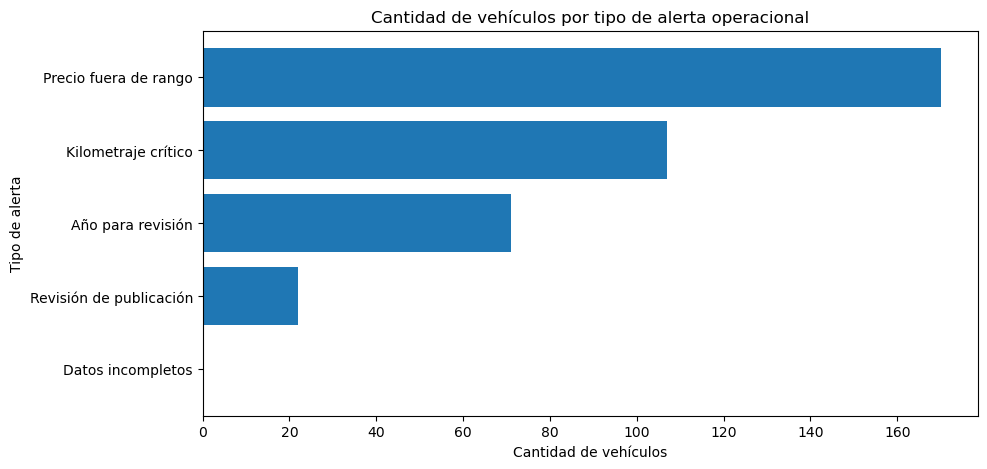

,tipo_alerta,cantidad
3,Datos incompletos,0
4,Revisión de publicación,22
1,Año para revisión,71
0,Kilometraje crítico,107
2,Precio fuera de rango,170


In [15]:
df_alertas = pd.DataFrame({
    "tipo_alerta": [
        "Kilometraje crítico",
        "Año para revisión",
        "Precio fuera de rango",
        "Datos incompletos",
        "Revisión de publicación"
    ],
    "cantidad": [
        int(df_op["alerta_km_critico"].sum()),
        int(df_op["alerta_year_revision"].sum()),
        int(df_op["alerta_precio_fuera_rango"].sum()),
        int(df_op["alerta_datos_incompletos"].sum()),
        int(df_op["alerta_revision_publicacion"].sum())
    ]
}).sort_values("cantidad", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_alertas["tipo_alerta"], df_alertas["cantidad"])
plt.title("Cantidad de vehículos por tipo de alerta operacional")
plt.xlabel("Cantidad de vehículos")
plt.ylabel("Tipo de alerta")
plt.show()

df_alertas

## Storytelling gráfico 2: Distribución de alertas operacionales

Este gráfico muestra qué tipo de alerta se repite con mayor frecuencia dentro de la base operacional.

La decisión operacional asociada es asignar la revisión diaria según el problema más frecuente. Si predominan los datos incompletos, el supervisor debe priorizar la corrección de publicaciones. Si predominan los kilometrajes críticos, la revisión debe enfocarse en vehículos con mayor nivel de uso antes de ser publicados o destacados.

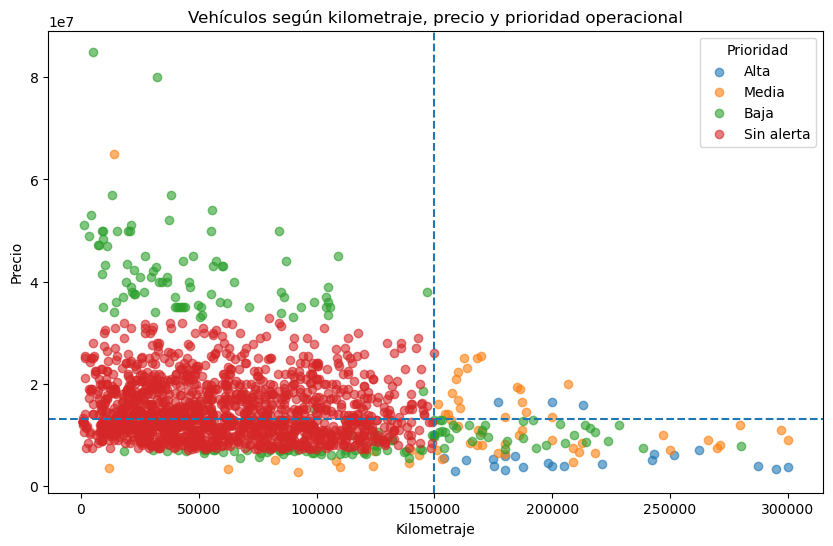

In [16]:
plt.figure(figsize=(10, 6))

for prioridad in orden:
    subset = df_op[df_op["prioridad_operacional"] == prioridad]
    plt.scatter(
        subset["km_op"],
        subset["precio_op"],
        alpha=0.6,
        label=prioridad
    )

plt.axvline(umbral_km, linestyle="--")
plt.axhline(precio_mediano, linestyle="--")

plt.title("Vehículos según kilometraje, precio y prioridad operacional")
plt.xlabel("Kilometraje")
plt.ylabel("Precio")
plt.legend(title="Prioridad")
plt.show()

## Storytelling gráfico 3: Mapa operacional de kilometraje y precio

Este gráfico permite observar cada vehículo según su kilometraje, precio y prioridad operacional.

La línea vertical indica el umbral de kilometraje crítico y la línea horizontal representa el precio mediano. La decisión operacional es identificar vehículos que combinan alto kilometraje, precio elevado o acumulación de alertas, para revisarlos antes de publicarlos o destacarlos comercialmente.

In [17]:
columnas_mostrar = [
    "prioridad_operacional",
    "total_alertas",
    "marca_op",
    "modelo_op",
    "year_op",
    "km_op",
    "precio_op",
    "ciudad_op",
    "combustible_op",
    "alerta_km_critico",
    "alerta_year_revision",
    "alerta_precio_fuera_rango",
    "alerta_datos_incompletos",
    "alerta_revision_publicacion",
    "url_op"
]

df_revision = df_op[columnas_mostrar].sort_values(
    ["total_alertas", "km_op"],
    ascending=[False, False]
)

df_revision.head(50)

,prioridad_operacional,total_alertas,marca_op,modelo_op,year_op,km_op,precio_op,ciudad_op,combustible_op,alerta_km_critico,alerta_year_revision,alerta_precio_fuera_rango,alerta_datos_incompletos,alerta_revision_publicacion,url_op
1486,Alta,3,Jeep,Patriot,2008,300000.0,3800000.0,Cerrillos,Bencina,True,True,True,False,False,https://www.yapo.cl/autos-usados/jeep-patriot-...
1582,Alta,3,Peugeot,407,2008,295000.0,3400000.0,Curacautin,Diesel,True,True,True,False,False,https://www.yapo.cl/autos-usados/peugeot-407-2...
387,Alta,3,Mitsubishi,L-300,1991,287232.0,4000000.0,Iquique,Diesel,True,True,True,False,False,https://www.autocosmos.cl/auto/usado/mitsubish...
1543,Alta,3,Hyundai,Tucson,2012,262233.0,6990000.0,La Serena,Bencina,True,True,True,False,False,https://www.yapo.cl/autos-usados/new-hyundai-t...
1557,Alta,3,Nissan,Qashqai,2013,251522.0,5990000.0,Santiago,Bencina,True,True,True,False,False,https://www.yapo.cl/autos-usados/nissan-qashqa...
406,Alta,3,Ssangyong,Korando,2014,243000.0,6200000.0,Melipilla,Diesel,True,True,True,False,False,https://www.autocosmos.cl/auto/usado/ssangyong...
1657,Alta,3,Toyota,Rav4,2008,242200.0,5000000.0,Vitacura,Bencina,True,True,True,False,False,https://www.yapo.cl/autos-usados/toyota-rav-4/...
1318,Alta,3,Nissan,Murano,2008,221000.0,4280000.0,Providencia,Bencina,True,True,True,False,False,https://www.yapo.cl/autos-usados/2008-nissan-m...
327,Alta,3,Toyota,4Runner Sr5 4.0,2012,213000.0,15890000.0,Araucania,Bencina,True,True,False,False,True,https://automoviles.emol.com/venta/autos/toyot...
400,Alta,3,Peugeot,Partner,2012,205000.0,4000000.0,La Serena,Diesel,True,True,True,False,False,https://www.autocosmos.cl/auto/usado/peugeot/p...


## Conclusión operacional

El análisis desarrollado permite transformar la base `Contenedor_Autos_Limpio1` en una herramienta de supervisión operacional.

Los KPIs utilizados son 100% operacionales, ya que permiten revisar diariamente vehículos con prioridad alta, kilometraje crítico, precios fuera de rango, publicaciones incompletas y unidades que requieren revisión antes de ser publicadas o destacadas.

La principal decisión que entrega este análisis es priorizar la revisión de vehículos según alertas concretas, permitiendo que el supervisor trabaje de forma más ordenada y basada en datos.

## KPIs operacionales complementarios

Además de los KPIs principales ya construidos, se incorporan indicadores complementarios orientados a la supervisión diaria de la base.

Estos KPIs permiten detectar problemas más operativos, como publicaciones sin enlace válido, vehículos duplicados, uso anual poco coherente, marcas con baja cantidad de registros y valores extremos en precio por kilómetro.

El objetivo es entregar al supervisor una segunda capa de revisión para mejorar la calidad de los datos y priorizar casos que requieren validación manual.

In [27]:
# ==========================================
# KPIs OPERACIONALES COMPLEMENTARIOS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Año actual para calcular antigüedad del vehículo
anio_actual = pd.Timestamp.today().year

# Antigüedad del vehículo
df_op["antiguedad_op"] = (anio_actual - df_op["year_op"]).clip(lower=1)

# Uso anual estimado: kilometraje dividido por antigüedad
df_op["uso_anual_estimado"] = df_op["km_op"] / df_op["antiguedad_op"]

# Precio por kilómetro
df_op["precio_por_km"] = np.where(
    df_op["km_op"] > 0,
    df_op["precio_op"] / df_op["km_op"],
    np.nan
)

# ------------------------------------------
# Nueva alerta 1: uso anual crítico
# Vehículos con más de 30.000 km por año
# ------------------------------------------
df_op["alerta_uso_anual_critico"] = df_op["uso_anual_estimado"] > 30000

# ------------------------------------------
# Nueva alerta 2: uso anual sospechosamente bajo
# Vehículos con más de 5 años y menos de 3.000 km por año
# ------------------------------------------
df_op["alerta_uso_anual_bajo"] = (
    (df_op["antiguedad_op"] >= 5) &
    (df_op["uso_anual_estimado"] < 3000)
)

# ------------------------------------------
# Nueva alerta 3: publicación sin URL válida
# ------------------------------------------
if "url_op" not in df_op.columns:
    df_op["url_op"] = ""

df_op["alerta_sin_url"] = (
    df_op["url_op"].isna() |
    df_op["url_op"].astype(str).str.strip().isin(["", "nan", "None", "Sin url"]) |
    (df_op["url_op"].astype(str).str.len() < 8)
)

# ------------------------------------------
# Nueva alerta 4: posible duplicado operacional
# Mismo vehículo según marca, modelo, año, km y precio
# ------------------------------------------
columnas_duplicado = ["marca_op", "modelo_op", "year_op", "km_op", "precio_op"]

df_op["alerta_posible_duplicado"] = df_op.duplicated(
    subset=columnas_duplicado,
    keep=False
)

# ------------------------------------------
# Nueva alerta 5: precio por kilómetro fuera de rango
# Se usa percentil 5 y 95 para detectar extremos
# ------------------------------------------
serie_ppkm = df_op["precio_por_km"].replace([np.inf, -np.inf], np.nan).dropna()

if len(serie_ppkm) >= 10:
    limite_ppkm_bajo = serie_ppkm.quantile(0.05)
    limite_ppkm_alto = serie_ppkm.quantile(0.95)

    df_op["alerta_precio_km_extremo"] = (
        (df_op["precio_por_km"] <= limite_ppkm_bajo) |
        (df_op["precio_por_km"] >= limite_ppkm_alto)
    )
else:
    limite_ppkm_bajo = np.nan
    limite_ppkm_alto = np.nan
    df_op["alerta_precio_km_extremo"] = False

# ------------------------------------------
# Nueva alerta 6: marcas con baja muestra
# Marcas con 3 o menos registros
# ------------------------------------------
conteo_marcas = df_op["marca_op"].value_counts()
marcas_baja_muestra = conteo_marcas[conteo_marcas <= 3].index

df_op["alerta_marca_baja_muestra"] = df_op["marca_op"].isin(marcas_baja_muestra)

print("KPIs complementarios creados correctamente")
print("Límite precio/km bajo:", limite_ppkm_bajo)
print("Límite precio/km alto:", limite_ppkm_alto)

KPIs complementarios creados correctamente
Límite precio/km bajo: 57.15459525258673
Límite precio/km alto: 1899.8405623615101


In [28]:
# ==========================================
# TABLA DE KPIs OPERACIONALES COMPLEMENTARIOS
# ==========================================

total_vehiculos = len(df_op)

def porcentaje_operacional(condicion):
    return round((condicion.sum() / total_vehiculos) * 100, 2)

tabla_kpis_complementarios = pd.DataFrame({
    "Nivel": [
        "Operacional",
        "Operacional",
        "Operacional",
        "Operacional",
        "Operacional",
        "Operacional"
    ],
    "KPI operacional complementario": [
        "% vehículos con uso anual crítico",
        "% vehículos con uso anual sospechosamente bajo",
        "% publicaciones sin URL válida",
        "% vehículos posiblemente duplicados",
        "% vehículos con precio por km fuera de rango",
        "% vehículos de marcas con baja muestra"
    ],
    "Objetivo operacional": [
        "Detectar vehículos con uso intensivo para revisión prioritaria",
        "Revisar kilometrajes poco coherentes con la antigüedad del vehículo",
        "Corregir publicaciones sin enlace o con enlace inválido",
        "Detectar registros repetidos antes de reportar o publicar",
        "Identificar valores extremos considerando precio y kilometraje",
        "Evitar decisiones basadas en marcas con poca representación"
    ],
    "Frecuencia": [
        "Diaria",
        "Diaria",
        "Diaria",
        "Diaria",
        "Semanal",
        "Semanal"
    ],
    "Datos utilizados": [
        "km_op, year_op, antiguedad_op",
        "km_op, year_op, uso_anual_estimado",
        "url_op",
        "marca_op, modelo_op, year_op, km_op, precio_op",
        "precio_op, km_op, precio_por_km",
        "marca_op"
    ],
    "Valor KPI (%)": [
        porcentaje_operacional(df_op["alerta_uso_anual_critico"]),
        porcentaje_operacional(df_op["alerta_uso_anual_bajo"]),
        porcentaje_operacional(df_op["alerta_sin_url"]),
        porcentaje_operacional(df_op["alerta_posible_duplicado"]),
        porcentaje_operacional(df_op["alerta_precio_km_extremo"]),
        porcentaje_operacional(df_op["alerta_marca_baja_muestra"])
    ]
})

tabla_kpis_complementarios

,Nivel,KPI operacional complementario,Objetivo operacional,Frecuencia,Datos utilizados,Valor KPI (%)
0,Operacional,% vehículos con uso anual crítico,Detectar vehículos con uso intensivo para revi...,Diaria,"km_op, year_op, antiguedad_op",10.86
1,Operacional,% vehículos con uso anual sospechosamente bajo,Revisar kilometrajes poco coherentes con la an...,Diaria,"km_op, year_op, uso_anual_estimado",0.30
2,Operacional,% publicaciones sin URL válida,Corregir publicaciones sin enlace o con enlace...,Diaria,url_op,0.00
3,Operacional,% vehículos posiblemente duplicados,Detectar registros repetidos antes de reportar...,Diaria,"marca_op, modelo_op, year_op, km_op, precio_op",0.71
4,Operacional,% vehículos con precio por km fuera de rango,Identificar valores extremos considerando prec...,Semanal,"precio_op, km_op, precio_por_km",10.09
5,Operacional,% vehículos de marcas con baja muestra,Evitar decisiones basadas en marcas con poca r...,Semanal,marca_op,0.00


### Storytelling de los KPIs complementarios

Los KPIs complementarios permiten profundizar el control operacional de la base. Mientras los primeros indicadores ayudan a identificar prioridad, kilometraje crítico y precios fuera de rango, estos nuevos KPIs permiten revisar la calidad y coherencia de los registros.

La decisión operacional principal es mejorar la revisión diaria del inventario. Si existen publicaciones sin URL válida, el supervisor debe corregir esos enlaces. Si aparecen posibles duplicados, se deben revisar antes de informar resultados. Si el uso anual estimado es muy alto o demasiado bajo, el vehículo requiere validación porque su kilometraje puede afectar la interpretación del precio y del estado del auto.

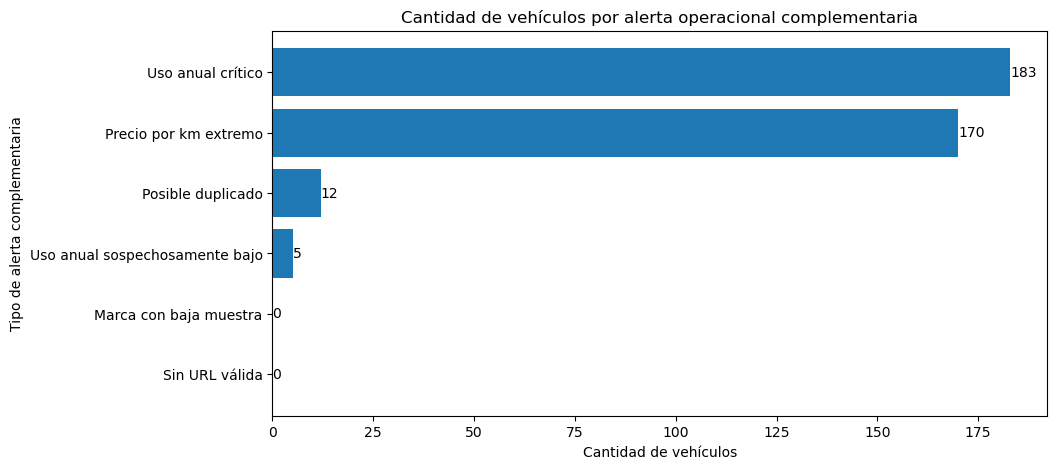

,alerta_complementaria,cantidad_vehiculos
2,Sin URL válida,0
5,Marca con baja muestra,0
1,Uso anual sospechosamente bajo,5
3,Posible duplicado,12
4,Precio por km extremo,170
0,Uso anual crítico,183


In [29]:
# ==========================================
# GRÁFICO 4: ALERTAS OPERACIONALES COMPLEMENTARIAS
# ==========================================

df_alertas_complementarias = pd.DataFrame({
    "alerta_complementaria": [
        "Uso anual crítico",
        "Uso anual sospechosamente bajo",
        "Sin URL válida",
        "Posible duplicado",
        "Precio por km extremo",
        "Marca con baja muestra"
    ],
    "cantidad_vehiculos": [
        int(df_op["alerta_uso_anual_critico"].sum()),
        int(df_op["alerta_uso_anual_bajo"].sum()),
        int(df_op["alerta_sin_url"].sum()),
        int(df_op["alerta_posible_duplicado"].sum()),
        int(df_op["alerta_precio_km_extremo"].sum()),
        int(df_op["alerta_marca_baja_muestra"].sum())
    ]
}).sort_values("cantidad_vehiculos", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(
    df_alertas_complementarias["alerta_complementaria"],
    df_alertas_complementarias["cantidad_vehiculos"]
)

plt.title("Cantidad de vehículos por alerta operacional complementaria")
plt.xlabel("Cantidad de vehículos")
plt.ylabel("Tipo de alerta complementaria")

for i, valor in enumerate(df_alertas_complementarias["cantidad_vehiculos"]):
    plt.text(valor, i, str(valor), va="center")

plt.show()

df_alertas_complementarias

## Storytelling gráfico 4: Alertas operacionales complementarias

Este gráfico muestra qué alertas complementarias aparecen con mayor frecuencia en la base.

La decisión operacional es enfocar la supervisión en el problema más repetido. Si predominan los registros sin URL válida, la prioridad será corregir publicaciones. Si predominan los posibles duplicados, se debe depurar la base antes de presentar resultados. Si aparecen muchos casos de uso anual crítico, se deben revisar esos vehículos con mayor detalle.

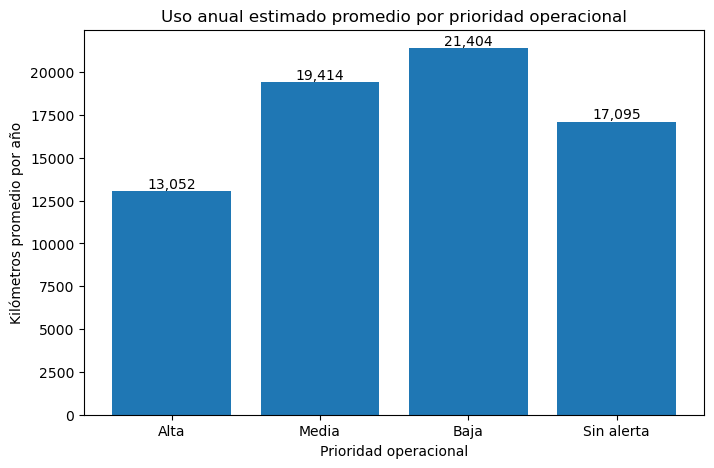

,prioridad_operacional,uso_anual_estimado
0,Alta,13051.897753
2,Media,19413.975838
1,Baja,21404.069515
3,Sin alerta,17094.888249


In [30]:
# ==========================================
# GRÁFICO 5: USO ANUAL ESTIMADO POR PRIORIDAD
# ==========================================

df_uso_prioridad = df_op.groupby("prioridad_operacional")["uso_anual_estimado"].mean().reset_index()

orden_prioridad = ["Alta", "Media", "Baja", "Sin alerta"]

df_uso_prioridad["prioridad_operacional"] = pd.Categorical(
    df_uso_prioridad["prioridad_operacional"],
    categories=orden_prioridad,
    ordered=True
)

df_uso_prioridad = df_uso_prioridad.sort_values("prioridad_operacional")

plt.figure(figsize=(8, 5))
plt.bar(
    df_uso_prioridad["prioridad_operacional"].astype(str),
    df_uso_prioridad["uso_anual_estimado"]
)

plt.title("Uso anual estimado promedio por prioridad operacional")
plt.xlabel("Prioridad operacional")
plt.ylabel("Kilómetros promedio por año")

for i, valor in enumerate(df_uso_prioridad["uso_anual_estimado"]):
    plt.text(i, valor, f"{valor:,.0f}", ha="center", va="bottom")

plt.show()

df_uso_prioridad

## Storytelling gráfico 5: Uso anual estimado por prioridad operacional

Este gráfico compara el uso anual estimado promedio según la prioridad operacional de los vehículos.

La decisión operacional es validar si los vehículos con mayor prioridad también presentan un uso anual más elevado. Si la prioridad alta concentra mayor uso anual estimado, el supervisor puede utilizar este indicador como apoyo para revisar primero esos vehículos, ya que presentan mayor desgaste relativo.

In [31]:
# ==========================================
# LISTADO DE VEHÍCULOS CON ALERTAS COMPLEMENTARIAS
# ==========================================

columnas_alertas_complementarias = [
    "alerta_uso_anual_critico",
    "alerta_uso_anual_bajo",
    "alerta_sin_url",
    "alerta_posible_duplicado",
    "alerta_precio_km_extremo",
    "alerta_marca_baja_muestra"
]

df_op["total_alertas_complementarias"] = df_op[columnas_alertas_complementarias].sum(axis=1)

columnas_revision_complementaria = [
    "marca_op",
    "modelo_op",
    "year_op",
    "km_op",
    "precio_op",
    "antiguedad_op",
    "uso_anual_estimado",
    "precio_por_km",
    "prioridad_operacional",
    "total_alertas",
    "total_alertas_complementarias",
    "alerta_uso_anual_critico",
    "alerta_uso_anual_bajo",
    "alerta_sin_url",
    "alerta_posible_duplicado",
    "alerta_precio_km_extremo",
    "alerta_marca_baja_muestra",
    "url_op"
]

columnas_existentes = [c for c in columnas_revision_complementaria if c in df_op.columns]

df_revision_complementaria = df_op[columnas_existentes].sort_values(
    ["total_alertas_complementarias", "total_alertas", "km_op"],
    ascending=[False, False, False]
)

df_revision_complementaria.head(50)

,marca_op,modelo_op,year_op,km_op,precio_op,antiguedad_op,uso_anual_estimado,precio_por_km,prioridad_operacional,total_alertas,total_alertas_complementarias,alerta_uso_anual_critico,alerta_uso_anual_bajo,alerta_sin_url,alerta_posible_duplicado,alerta_precio_km_extremo,alerta_marca_baja_muestra,url_op
365,Volkswagen,Voyage Voyage 1.6 Highline,2022,151000.0,6950000.0,4,37750.000000,46.026490,Media,2,2,True,False,False,False,True,False,https://automoviles.emol.com/venta/autos/volks...
1426,Ford,--,2009,14000.0,65000000.0,17,823.529412,4642.857143,Media,2,2,False,True,False,False,True,False,https://www.yapo.cl/autos-usados/gt-500-shelby...
1533,Mg,Mg3,2022,280000.0,7790000.0,4,70000.000000,27.821429,Baja,1,2,True,False,False,False,True,False,https://www.yapo.cl/autos-usados/mg-3/32434291
424,Chevrolet,D-Max,2020,228259.0,11990000.0,6,38043.166667,52.528049,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...
414,Peugeot,Partner,2022,223583.0,8890000.0,4,55895.750000,39.761520,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...
311,Ssangyong,Musso 2.2 4X2,2022,216140.0,11250000.0,4,54035.000000,52.049597,Baja,1,2,True,False,False,False,True,False,https://automoviles.emol.com/venta/autos/ssang...
420,Peugeot,Partner,2022,214397.0,8590000.0,4,53599.250000,40.065859,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...
430,Peugeot,Partner,2023,209238.0,9900000.0,3,69746.000000,47.314541,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...
415,Peugeot,Partner,2022,205523.0,8490000.0,4,51380.750000,41.309245,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...
440,Peugeot,Partner,2021,197522.0,8000000.0,5,39504.400000,40.501818,Baja,1,2,True,False,False,False,True,False,https://www.autoselect.cl/web/vehiculos/view?i...


## Conclusión de KPIs operacionales complementarios

Los KPIs complementarios fortalecen el análisis operacional porque permiten revisar aspectos que no siempre se detectan con los indicadores principales.

A nivel de supervisión, estos indicadores ayudan a identificar publicaciones sin URL válida, posibles duplicados, uso anual incoherente, marcas con baja muestra y precios por kilómetro fuera de rango.

La decisión operacional final es usar estos KPIs como una segunda capa de control antes de publicar, destacar o analizar vehículos. De esta forma, el equipo puede reducir errores en la base, mejorar la calidad de las publicaciones y priorizar revisiones con criterios más concretos.